<div style="background-color: #73DEC0; border-left: 10px solid #730707; padding: 22px; border-radius: 6px;">
  <h1 style="color: #730707; margin: 0; font-weight: bold; font-size: 32px; line-height: 1.2;">
    Uncharging The Future: An End-to-End Analysis of Electric Vehicle Adoption and Market Trends in Washington State
  </h1>
</div>

<div style="background-color: #E0F2FE;  solid #0284C7; padding: 15px; border-radius: 4px; margin: 10px 0;">
  <strong style="color: #0369A1; font-size: 16px;">🎯 Primary Objective:</strong>
  <p style="color: #0C4A6E; margin-top: 5px; margin-bottom: 0; font-size: 16px;">
    Analyze public records from the Washington State Department of Licensing (DOL) to evaluate EV adoption curves, market share dominance, technological range progression, and infrastructure equity across legislative districts and utilities.
  </p>
</div>

<div style="background-color: border-left: 6px solid #059669; padding: 14px; border-radius: 6px; margin-bottom: 12px;">
  <h3 style="color: #0369A1; margin: 0; font-size: 18px; font-weight: bold;">
      File Source: 
  </h3>
</div>

 https://catalog.data.gov/dataset/electric-vehicle-population-data

<div style="background-color:  border-left: 6px solid #059669; padding: 14px; border-radius: 6px; margin-bottom: 12px;">
  <h3 style="color: #0369A1; margin: 0; font-size: 18px; font-weight: bold;">
       Total Volume: 
  </h3>
</div>

<div style="background-color:  border-left: 6px solid #059669; padding: 14px; border-radius: 6px; margin-bottom: 12px;">
  <h3 style="color: #0369A1; margin: 0; font-size: 18px; font-weight: bold;">
       Variables: 
  </h3>
</div>

 

| Field Name | Description |
|---|---|
| `VIN (1-10)` | First 10 digits of the Vehicle Identification Number. |
| `County` | County of vehicle registration. |
| `City` | City of vehicle registration. |
| `State` | U.S. State of vehicle registration. |
| `Postal Code` | 5-digit ZIP code of registered location. |
| `Model Year` | Vehicle manufacturing model year. |
| `Make` | Vehicle manufacturer (e.g., Tesla, Nissan). |
| `Model` | Vehicle model name (e.g., Model 3, Leaf). |
| `Electric Vehicle Type` | EV powertrain technology (BEV vs. PHEV). |
| `Clean Alternative Fuel Vehicle (CAFV) Eligibility` | CAFV tax incentive eligibility status. |
| `Electric Range` | Maximum battery range in miles. |
| `Legislative District` | State legislative district identifier. |
| `DOL Vehicle ID` | Unique vehicle ID assigned by DOL. |
| `Vehicle Location` | Coordinates formatted as `POINT (Lon Lat)`. |
| `Electric Utility` | Power utility provider for the area. |
| `2020 Census Tract` | 11-digit U.S. Census tract identifier. |

![Electric Vehicle Analytics Banner](https://images.unsplash.com/photo-1593941707882-a5bba14938c7?auto=format&fit=crop&w=1200&q=80)

<h1 style="text-align:center; color:green; font-weight:bold;">**Data Loading and Initial Overview **</h1>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_excel('ev data set.xlsx')
df_clean = df.copy()

In [3]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10


In [4]:
df.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
294188,YV1H60EP7P,Jefferson,Port Townsend,WA,98368.0,2023,VOLVO,V60,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,41.0,24.0,236211300,POINT (-122.77263 48.1212),BONNEVILLE POWER ADMINISTRATION||PUGET SOUND E...,5.303195e+10
294189,5YJ3E1EB3L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,14.0,292558003,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
294190,KNDCR3L13S,King,Seattle,WA,98118.0,2025,KIA,NIRO,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,282972294,POINT (-122.28083 47.54693),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
294191,JTDKARFP0H,Pierce,Lakewood,WA,98499.0,2017,TOYOTA,PRIUS PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,28.0,168423146,POINT (-122.51495 47.16196),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
294192,5YJ3E1EA6L,Snohomish,Bothell,WA,98021.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,1.0,137123871,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10


In [5]:
print( df.shape)

(294193, 16)


In [6]:
print(df.dtypes)

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: object


In [7]:
print(df.info)

<bound method DataFrame.info of         VIN (1-10)     County           City State  Postal Code  Model Year  \
0       5YJ3E1EA5L     Yakima         Yakima    WA      98908.0        2020   
1       5YJ3E1EA9K   Thurston        Olympia    WA      98502.0        2019   
2       5YJSA1H22F     Kitsap       Kingston    WA      98346.0        2015   
3       KM8K33AG7L       King        Seattle    WA      98107.0        2020   
4       5YJ3E1EB1K     Yakima         Yakima    WA      98902.0        2019   
...            ...        ...            ...   ...          ...         ...   
294188  YV1H60EP7P  Jefferson  Port Townsend    WA      98368.0        2023   
294189  5YJ3E1EB3L     Yakima         Yakima    WA      98908.0        2020   
294190  KNDCR3L13S       King        Seattle    WA      98118.0        2025   
294191  JTDKARFP0H     Pierce       Lakewood    WA      98499.0        2017   
294192  5YJ3E1EA6L  Snohomish        Bothell    WA      98021.0        2020   

           Make    

In [8]:
 df.sample()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
149978,1G1RD6E4XD,King,Seattle,WA,98118.0,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38.0,37.0,114501572,POINT (-122.28083 47.54693),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303301e+10


In [9]:
print(df.columns)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')


<h1 style="text-align:center; color:green; font-weight:bold;">**Data Pre-processing  **</h1>


In [10]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                10
City                                                  10
State                                                  0
Postal Code                                           10
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        13
Legislative District                                 762
DOL Vehicle ID                                         0
Vehicle Location                                      18
Electric Utility                                      10
2020 Census Tract                                     10
dtype: int64

#### <span style="color:red">🔴 Handling & Fill Missing Values </span>

In [11]:
df['County'] = df['County'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
df['Electric Utility'] = df['Electric Utility'].fillna('Unknown')
df['Vehicle Location'] = df['Vehicle Location'].fillna('Unknown')

In [12]:
df['Postal Code'] = df['Postal Code'].fillna(-1)
df['Legislative District'] = df['Legislative District'].fillna(-1)
df['2020 Census Tract'] = df['2020 Census Tract'].fillna(-1)

In [13]:
df['Electric Range'] = df['Electric Range'].fillna(0)

In [14]:
print("Remaining null values:", df.isnull().sum().sum())

Remaining null values: 0


#### <span style="color:red">🔴Removing duplicates </span>

In [15]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### <span style="color:red">🔴 Correcting data types </span>

In [16]:
df['Postal Code'] = df['Postal Code'].apply(lambda x: str(int(x)) if pd.notnull(x) else 'Unknown')
df['2020 Census Tract'] = df['2020 Census Tract'].apply(lambda x: str(int(x)) if pd.notnull(x) else 'Unknown')
df['DOL Vehicle ID'] = df['DOL Vehicle ID'].astype(str)
df['Legislative District'] = df['Legislative District'].astype('Int64')

In [17]:
df['Make'] = df['Make'].astype('category')
df['Electric Vehicle Type'] = df['Electric Vehicle Type'].astype('category')

In [18]:
print(df.dtypes)

VIN (1-10)                                             object
County                                                 object
City                                                   object
State                                                  object
Postal Code                                            object
Model Year                                              int64
Make                                                 category
Model                                                  object
Electric Vehicle Type                                category
Clean Alternative Fuel Vehicle (CAFV) Eligibility      object
Electric Range                                        float64
Legislative District                                    Int64
DOL Vehicle ID                                         object
Vehicle Location                                       object
Electric Utility                                       object
2020 Census Tract                                      object
dtype: o

#### <span style="color:red">🔴 Create Derived Columns </span>

In [19]:
# 1. Calculate Vehicle Age
df['Vehicle_Age'] = 2026 - df['Model Year']

In [20]:
# 2. Binary Indicator for BEV vs PHEV
df['Is_BEV'] = (df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)').astype(int)

In [21]:
# 3. Binary Indicator for Tesla Vehicles
df['Is_Tesla'] = (df['Make'] == 'TESLA').astype(int)

In [22]:
# 4. Binary Indicator for Clean Alternative Fuel Vehicle (CAFV) Eligibility
df['Is_CAFV_Eligible'] = (
    df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible'
).astype(int)

In [23]:
# 5. Extract Longitude and Latitude numerical floats
coords = df['Vehicle Location'].str.extract(r'POINT \((?P<Longitude>-?\d+\.\d+) (?P<Latitude>-?\d+\.\d+)\)')
df['Longitude'] = coords['Longitude'].astype(float)
df['Latitude'] = coords['Latitude'].astype(float)

In [24]:
print(df[['Model Year', 'Vehicle_Age', 'Is_BEV', 'Is_Tesla', 'Is_CAFV_Eligible', 'Longitude', 'Latitude']].head())

   Model Year  Vehicle_Age  Is_BEV  Is_Tesla  Is_CAFV_Eligible  Longitude  \
0        2020            6       1         1                 1 -120.60272   
1        2019            7       1         1                 1 -122.92018   
2        2015           11       1         1                 1 -122.49770   
3        2020            6       1         0                 1 -122.38591   
4        2019            7       1         1                 1 -120.51904   

   Latitude  
0  46.59656  
1  47.04575  
2  47.79802  
3  47.67597  
4  46.59782  


#### <span style="color:red">🔴 Outliers Handling </span>

In [25]:
Q1 = df['Electric Range'].quantile(0.25)
Q3 = df['Electric Range'].quantile(0.75)
Q1,Q3

(np.float64(0.0), np.float64(32.0))

In [26]:
IQR = Q3 - Q1
IQR

np.float64(32.0)

In [27]:
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound,lower_bound

(np.float64(80.0), np.float64(-48.0))

In [28]:
outliers_range = df[(df['Electric Range'] < lower_bound) | (df['Electric Range'] > upper_bound)]
print(f"Upper Bound for Electric Range: {upper_bound}")
print(f"Number of Outliers in Electric Range: {len(outliers_range)} ({len(outliers_range)/len(df)*100:.2f}%)")

Upper Bound for Electric Range: 80.0
Number of Outliers in Electric Range: 42798 (14.55%)


#### <span style="color:red">🔴 Filtering and Aggregation </span>

In [29]:
# 1. Filter dataset for Washington state and recent models (2020+)
wa_recent_evs = df[(df['State'] == 'WA') & (df['Model Year'] >= 2020)]

In [30]:
print(wa_recent_evs)

        VIN (1-10)     County           City State Postal Code  Model Year  \
0       5YJ3E1EA5L     Yakima         Yakima    WA       98908        2020   
3       KM8K33AG7L       King        Seattle    WA       98107        2020   
8       7SAYGDEE0P     Yakima         Yakima    WA       98901        2023   
9       5YJ3E1EB6L     Kitsap     Silverdale    WA       98383        2020   
12      JA4T5VA92R   Thurston           Yelm    WA       98597        2024   
...            ...        ...            ...   ...         ...         ...   
294187  7PDSGABA2P  Snohomish       Stanwood    WA       98292        2023   
294188  YV1H60EP7P  Jefferson  Port Townsend    WA       98368        2023   
294189  5YJ3E1EB3L     Yakima         Yakima    WA       98908        2020   
294190  KNDCR3L13S       King        Seattle    WA       98118        2025   
294192  5YJ3E1EA6L  Snohomish        Bothell    WA       98021        2020   

              Make      Model                   Electric Vehicl

In [51]:
# 2. Aggregate WA recent EVs by County and Make
county_make_summary = wa_recent_evs.groupby(['County', 'Make'],observed=False).agg(
    Vehicle_Count=('DOL Vehicle ID', 'count'),
    Average_Range=('Electric Range', 'mean')
).reset_index().sort_values(by='Vehicle_Count', ascending=False)

In [32]:
print(county_make_summary.head(10))

         County       Make  Vehicle_Count  Average_Range
826        King      TESLA          53758      17.575003
1512  Snohomish      TESLA          15472      16.844687
1316     Pierce      TESLA           8119      20.788767
287       Clark      TESLA           6336      18.990688
803        King    HYUNDAI           5849       7.299538
790        King        BMW           5628      15.928394
806        King        KIA           5623      17.168771
822        King     RIVIAN           5214       0.000000
793        King  CHEVROLET           4872      35.617816
799        King       FORD           4848       2.380157


<h1 style="text-align:center; color:green; font-weight:bold;">**EDA & VISUALIZATIONS **</h1>


<h2 style="color: #2D3748; font-family: 'Segoe UI', sans-serif; font-weight: bold; padding-bottom: 5px;">
  UNIVARIATE ANALYSIS
</h2>


#### <span style="color:red">1.Group By </span>

In [33]:
# 1.Powertrain Technology Breakdown
print("=== GROUPBY SUMMARY BY Electric Vehicle Type ===")
powertrain_summary = df_clean.groupby('Electric Vehicle Type').agg(
    Vehicle_Count=('DOL Vehicle ID', 'count'),
    Avg_Electric_Range=('Electric Range', 'mean'),
    Median_Electric_Range=('Electric Range', 'median'),
    Avg_Model_Year=('Model Year', 'mean')
).reset_index()

display(powertrain_summary)

=== GROUPBY SUMMARY BY Electric Vehicle Type ===


,Electric Vehicle Type,Vehicle_Count,Avg_Electric_Range,Median_Electric_Range,Avg_Model_Year
0,Battery Electric Vehicle (BEV),237567,38.046437,0.0,2022.543994
1,Plug-in Hybrid Electric Vehicle (PHEV),56626,32.206490,32.0,2021.342157


#### <span style="color:red">2.Bar Plot-Top 10 EV Manufacturers by Total Registrations 

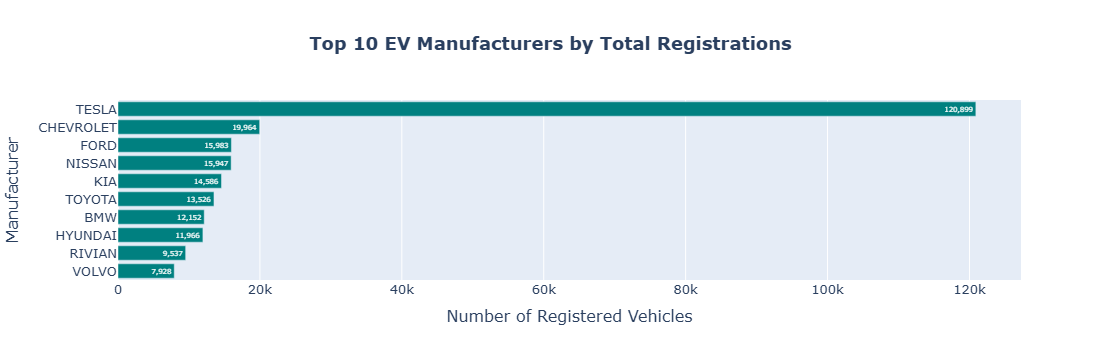

In [34]:
top_makes = df_clean['Make'].value_counts().head(10).reset_index()
top_makes.columns = ['Manufacturer', 'Count']
fig_bar = px.bar(
    top_makes, 
    x='Count', 
    y='Manufacturer',
    orientation='h',
    title='<b>Top 10 EV Manufacturers by Total Registrations</b>',
    color_discrete_sequence=['#008080'],  
    text_auto=',d'
)

fig_bar.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    title_x=0.5,
    xaxis_title="Number of Registered Vehicles",
    yaxis_title="Manufacturer",
    font=dict(size=13)
)

fig_bar.update_traces(
    hovertemplate='<b>%{y}</b><br>Total Registrations: %{x:,.0f}'
)

fig_bar.show()

#### <span style="color:red">3.Pie Chart - Powertrain Market Share (BEV vs. PHEV)</span>

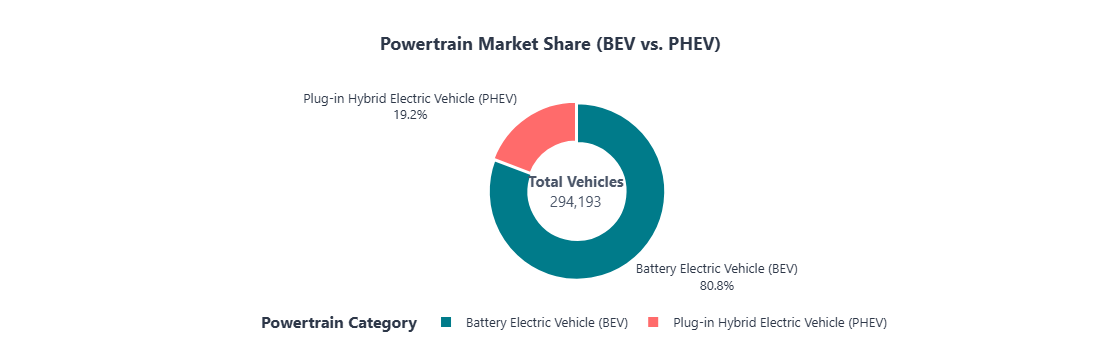

In [35]:
# Powertrain Market Share (BEV vs. PHEV)

powertrain_counts = df_clean['Electric Vehicle Type'].value_counts().reset_index()
powertrain_counts.columns = ['Powertrain Type', 'Count']
total_evs = powertrain_counts['Count'].sum()

fig_donut = px.pie(
    powertrain_counts, 
    values='Count', 
    names='Powertrain Type',
    title='<b>Powertrain Market Share (BEV vs. PHEV)</b>',
    hole=0.55,
    color='Powertrain Type',
    color_discrete_sequence=['#007B8A', '#FF6B6B']  
)

fig_donut.update_traces(
    textinfo='percent+label',
    textposition='outside',
    marker=dict(line=dict(color='#FFFFFF', width=2)),
    hovertemplate='<b>%{label}</b><br>Total Registrations: <b>%{value:,.0f}</b><br>Market Share: <b>%{percent}</b>',
    pull=[0.02, 0]  
)

fig_donut.update_layout(
    title_x=0.5,
    font=dict(
        family="Segoe UI, sans-serif",
        size=13,
        color="#2D3748"
    ),
    paper_bgcolor='#FFFFFF',
    annotations=[
        dict(
            text=f"<b>Total Vehicles</b><br>{total_evs:,.0f}",
            x=0.5, y=0.5,
            font_size=15,
            font_family="Segoe UI, sans-serif",
            font_color="#4A5568",
            showarrow=False
        )
    ],
    legend=dict(
        title="<b>Powertrain Category</b>",
        orientation="h",
        y=-0.15,
        x=0.5,
        xanchor="center"
    )
)

fig_donut.show()

<h2 style="color: #2D3748; font-family: 'Segoe UI', sans-serif; font-weight: bold; padding-bottom: 5px;">
  BIVARIATE ANALYSIS
</h2>


#### <span style="color:red">4. Pivot Table </span>

In [48]:
# Pivot Table: Top 5 Manufacturers by Powertrain Type
print("\n=== PIVOT TABLE: TOP 5 MAKES BY Electric Vehicle Type ===")
top_5_makes = df_clean['Make'].value_counts().head(5).index
pivot_make_type = pd.crosstab(
    df_clean[df_clean['Make'].isin(top_5_makes)]['Make'], 
    df_clean['Electric Vehicle Type'], 
    margins=True, 
    margins_name="Total"
)

display(pivot_make_type)


=== PIVOT TABLE: TOP 5 MAKES BY Electric Vehicle Type ===


Electric Vehicle Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV),Total
Make,,,
CHEVROLET,15616,4348,19964
FORD,12127,3856,15983
KIA,10183,4403,14586
NISSAN,15934,13,15947
TESLA,120899,0,120899
Total,174759,12620,187379


#### <span style="color:red">5. Bivariate scatter plots </span>

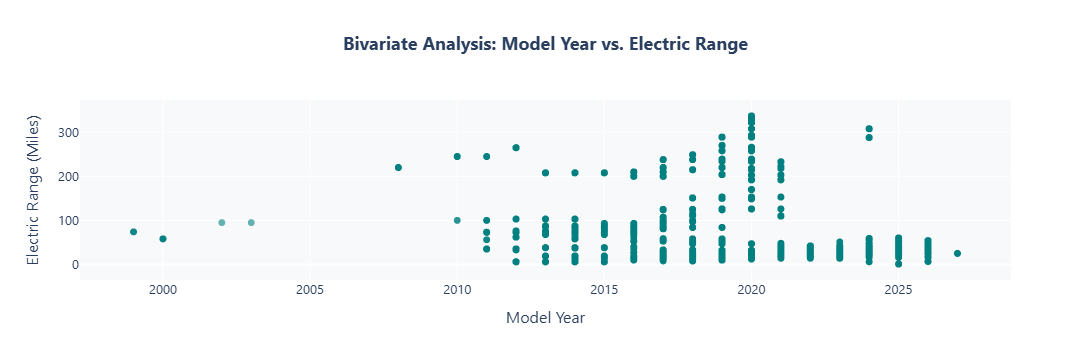

In [47]:
df_bivariate = df_clean[df_clean['Electric Range'] > 0]
fig_scatter = px.scatter(
    df_bivariate,
    x='Model Year',
    y='Electric Range',
    title='<b>Bivariate Analysis: Model Year vs. Electric Range</b>',
    color_discrete_sequence=['#008080'],
    opacity=0.6
)

fig_scatter.update_traces(
    marker=dict(size=7),
    hovertemplate='<b>Model Year: %{x}</b><br>Electric Range: %{y} miles'
)

fig_scatter.update_layout(
    title_x=0.5,
    xaxis_title="Model Year",
    yaxis_title="Electric Range (Miles)",
    font=dict(family="Segoe UI, sans-serif", size=13),
    paper_bgcolor='#FFFFFF',
    plot_bgcolor='#F8F9FA'
)

fig_scatter.show()

#### <span style="color:red"> 6.Line Chart: Growth Trajectory over Model Years (2010+)</span>

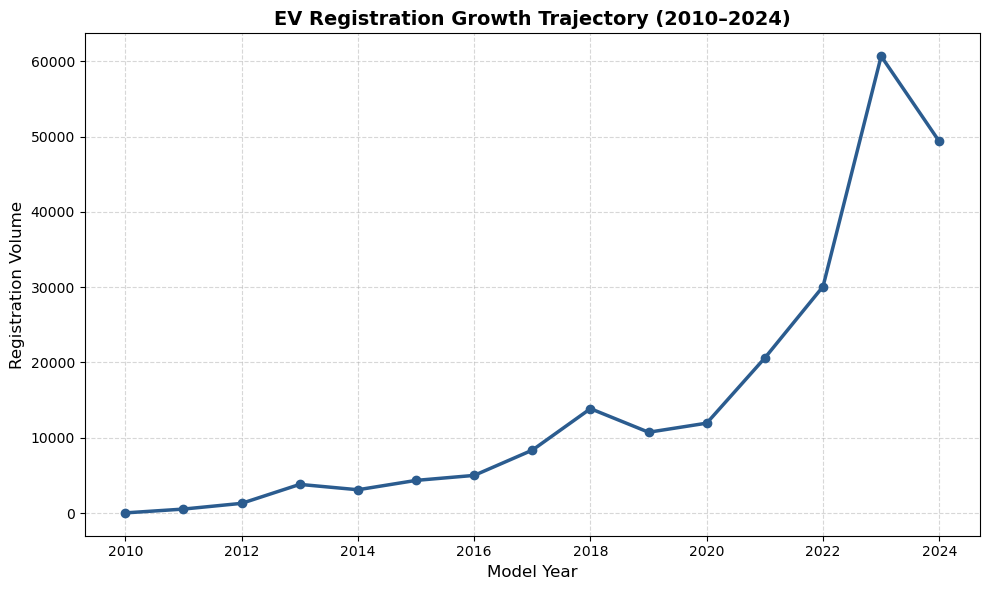

In [38]:
yearly_counts = df_clean[(df_clean['Model Year'] >= 2010) & (df_clean['Model Year'] <= 2024)]['Model Year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', color='#2b5c8f', linewidth=2.5, markersize=6)
plt.title("EV Registration Growth Trajectory (2010–2024)", fontsize=14, fontweight='bold')
plt.xlabel("Model Year", fontsize=12)
plt.ylabel("Registration Volume", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### <span style="color:red"> 7.Box Plot: "Electric Range Distribution by Powertrain Type"</span>

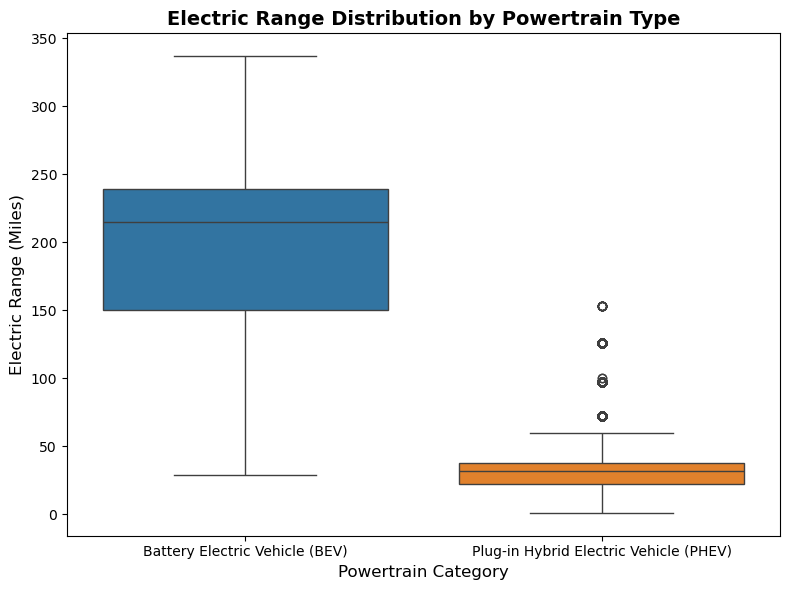

In [45]:

range_data = df_clean[df_clean['Electric Range'] > 0]

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=range_data,
    x='Electric Vehicle Type',
    y='Electric Range',
    hue='Electric Vehicle Type',
    palette=['#1f77b4', '#ff7f0e'],
    legend=False
)

plt.title("Electric Range Distribution by Powertrain Type", fontsize=14, fontweight='bold')
plt.xlabel("Powertrain Category", fontsize=12)
plt.ylabel("Electric Range (Miles)", fontsize=12)
plt.tight_layout()
plt.show()

<h2 style="color: #2D3748; font-family: 'Segoe UI', sans-serif; font-weight: bold; padding-bottom: 5px;">
  MULTIVARIATE ANALYSIS
</h2>


#### <span style="color:red"> 8.Scatter plot: Geographical Coordinates</span>

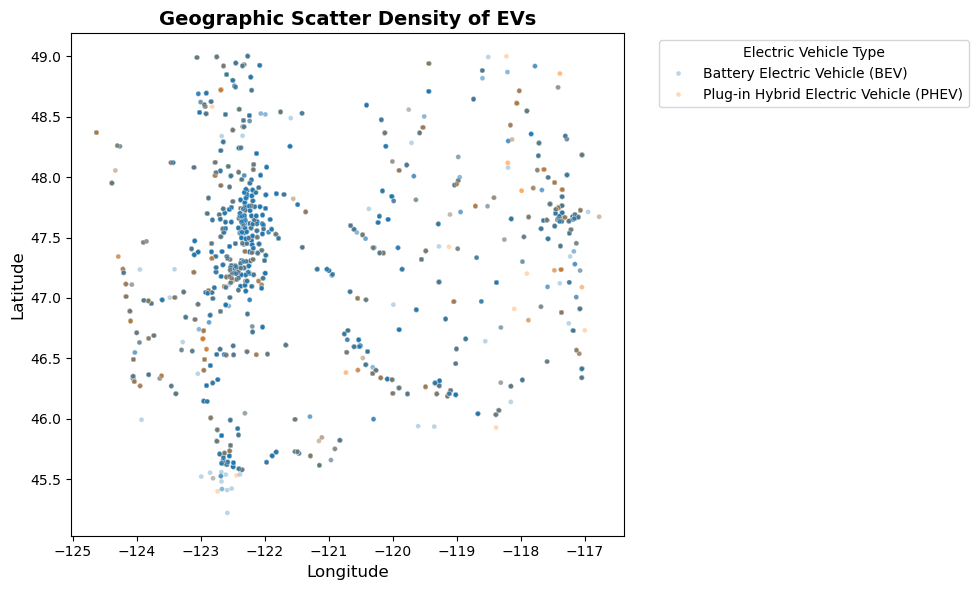

In [40]:
valid_coords = df.dropna(subset=['Latitude', 'Longitude'])
wa_coords = valid_coords[
    (valid_coords['Latitude'] >= 45) & (valid_coords['Latitude'] <= 49) & 
    (valid_coords['Longitude'] >= -125) & (valid_coords['Longitude'] <= -116)
]
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=wa_coords, 
    x='Longitude', 
    y='Latitude', 
    hue='Electric Vehicle Type', 
    alpha=0.3, 
    palette=['#1f77b4', '#ff7f0e'], 
    s=12
)
plt.title("Geographic Scatter Density of EVs", fontsize=14, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(title="Electric Vehicle Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("ev_geo_cafv_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

#### <span style="color:red">9.Correlation Analysis </span>

In [41]:
print("\n=== CORRELATION MATRIX ===")
num_cols = ['Model Year', 'Electric Range', 'Vehicle_Age', 'Legislative District']
corr_matrix = df[num_cols].corr()

display(corr_matrix)


=== CORRELATION MATRIX ===


,Model Year,Electric Range,Vehicle_Age,Legislative District
Model Year,1.000000,-0.550380,-1.000000,0.002049
Electric Range,-0.550380,1.000000,0.550380,0.002905
Vehicle_Age,-1.000000,0.550380,1.000000,-0.002049
Legislative District,0.002049,0.002905,-0.002049,1.000000


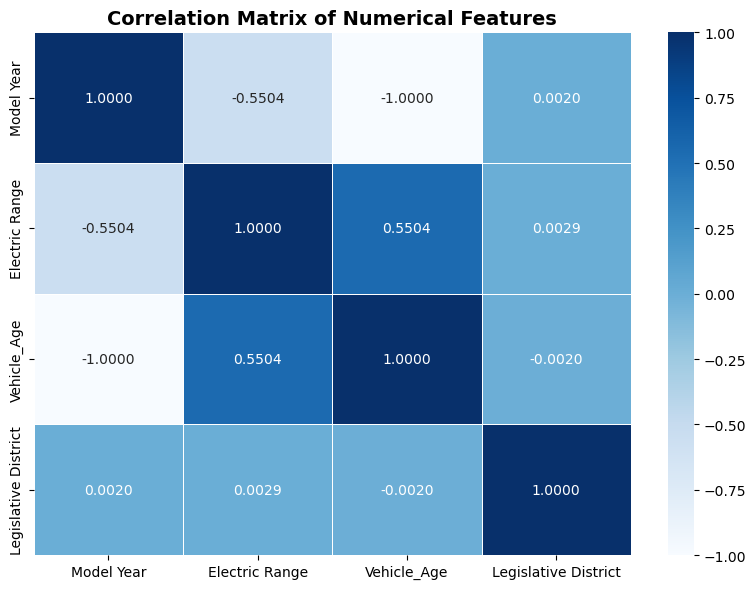

In [42]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.4f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### <span style="color:red">10.Stacked Bar Chart: CAFV Eligibility by Top 5 Makes </span>

In [43]:
top_5 = df_clean['Make'].value_counts().head(5).index
cafv_df = df_clean[df_clean['Make'].isin(top_5)]
cafv_grouped = (
    cafv_df.groupby(['Make', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
    .size()
    .reset_index(name='Count')
)

fig_grouped = px.bar(
    cafv_grouped,
    x='Make',
    y='Count',
    color='Clean Alternative Fuel Vehicle (CAFV) Eligibility',
    barmode='group',
    title='<b>CAFV Eligibility Breakdown by Top 5 Makes</b>',
    color_discrete_sequence=px.colors.qualitative.Bold, 
    text_auto=',d'
)

fig_grouped.update_layout(
    title_x=0.5,
    xaxis_title="Manufacturer",
    yaxis_title="Vehicle Count",
    legend=dict(
        title="<b>CAFV Status</b>",
        orientation="h",
        y=-0.25,
        x=0.5,
        xanchor="center"
    ),
    font=dict(size=12)
)

fig_grouped.show()

<h1 style="text-align:center; color:green; font-weight:bold;">** ─── Executive Summary & Key Strategic Insights ───**</h1>

## Executive Summary
This end-to-end analysis evaluated over 290,000 Electric Vehicle (EV) registrations across Washington State to uncover trends in market adoption, manufacturer dominance, technology performance, and policy efficacy. The findings highlight a rapidly accelerating transition toward zero-emission transportation, led overwhelmingly by Battery Electric Vehicles (BEVs) and concentrated heavily within major urban technology corridors.

### Key Analytical Takeaways

1.**Powertrain Evolution**(BEV Dominance):
Pure Battery Electric Vehicles (BEVs) hold the dominant market share over Plug-in Hybrid Electric Vehicles (PHEVs).
Consumer preference and manufacturer investment have decisively shifted toward fully electric platforms over the last decade, driven by expanding battery capacities and maturing charging infrastructure.

2.**Manufacturer Market Concentration**:
Tesla continues to lead total vehicle registrations across Washington State by a significant margin.
Legacy automakers (such as Chevrolet, Nissan, BMW, and Ford) retain strong secondary positions, but market share remains highly concentrated among the top 3–5 manufacturers.

3.**Incentive & Regulatory Impact (CAFV Eligibility)**:
A substantial majority of registered vehicles meet Clean Alternative Fuel Vehicle (CAFV) eligibility criteria.
Vehicles with non-eligible or unrated status are largely tied to legacy short-range PHEVs or newly introduced model years awaiting official EPA range testing.

4.**Geographic Clustering**:
EV adoption is heavily clustered around high-density metropolitan regions (primarily King County and surrounding Puget Sound districts).
Rural adoption lags behind, indicating that regional charging network density and socioeconomic demographics remain primary drivers of consumer uptake.

### Strategic Recommendations & Next Steps
1. **Infrastructure Allocation:** Expand public fast-charging networks into rural and eastern regional corridors to alleviate geographic density disparities.
2. **Policy Re-Evaluation:** Adjust incentive structures to support low-cost entry-level BEVs and extended-range PHEVs to accelerate adoption across diverse income demographics.
3. **Predictive Analytics (Future Scope):** Develop non-linear supervised machine learning models (e.g., Random Forest Classifier) to forecast future EV adoption rates and CAFV eligibility by zip code.